# Conditional Flow-Matching Training

Trains a conditional diffusion model to learn $p(x_{t+1} \mid x_t)$.

**What changes from the unconditional model:**
- Dataset returns consecutive pairs $(x_t, x_{t+1})$ instead of single frames
- `SongUNet` uses `in_channels=4` (2 channels for noisy $z_s$ + 2 channels for conditioning $x_t$ concatenated spatially)
- $x_t$ is passed as `class_labels` — concatenated inside `SongUNet.forward` before the encoder
- Training target is still $x_{t+1} - z_0$ (velocity), same formula as before
- `label_dropout=0.1` enables classifier-free guidance at inference if needed

Everything else (loss structure, optimiser, ODE sampler) is identical to the unconditional case.

## 1. Imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import csv
from natsort import natsorted

# Add SQG folder to path so we can import SongUNet
SQG_DIR = Path('SQG')
sys.path.insert(0, str(SQG_DIR))

from diffusion_networks import SongUNet

## 2. Config

In [ ]:
# ── data ──────────────────────────────────────────────────────────────────
DATA_DIR = Path('../data')
DATA_STD   = 2660.0                   # normalisation std (mean assumed 0)

# ── model ─────────────────────────────────────────────────────────────────
IMG_CHANNELS   = 2    # SQG has 2 vertical levels
IMG_RESOLUTION = 64
FILTERS        = 32
# label_dropout=0.1: 10% of training steps the conditioning is zeroed out.
# This forces the network to also learn the unconditional velocity,
# enabling classifier-free guidance at inference (scale between fidelity and diversity).
LABEL_DROPOUT  = 0.1

# ── training ──────────────────────────────────────────────────────────────
BATCH_SIZE   = 16
NUM_EPOCHS   = 50
LR           = 1e-3
WEIGHT_DECAY = 1e-4

# ── misc ──────────────────────────────────────────────────────────────────
SAVE_PATH = Path('../models/results/best_model_conditional.pth')
LOG_PATH  = Path('../models/results/training_log.csv')
# it's ok that you can just print it out
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 3. Dataset — consecutive pairs $(x_t,\, x_{t+1})$

The original `SQGDataset` returns single frames.
We add `SQGPairDataset` that returns consecutive pairs so the model
can learn $p(x_{t+1} \mid x_t)$.

In [ ]:
class SQGPairDataset(Dataset):
    """
    Returns (x_t, x_{t+1}) consecutive pairs drawn across multiple SQG trajectory files.

    Each file is one trajectory of shape (T, C, H, W).
    Trajectories are split into train/val by trajectory index, not by time,
    so every pair within a trajectory stays in the same split.

    Args:
        data_dir   : folder containing sqg_N64_3hrly_*.npy files
        std        : normalisation std (mean assumed 0)
        split      : 'train' or 'val'
        train_frac : fraction of trajectories used for training
    """
    def __init__(self, data_dir, std, split='train', train_frac=0.8):
        data_dir = Path(data_dir)
        files = natsorted(data_dir.glob('sqg_N64_1hrly_*.npy'))
        assert len(files) > 0, f"No files found in {data_dir}"

        cut = int(len(files) * train_frac)
        files = files[:cut] if split == 'train' else files[cut:]
        # should we shuffle at first?

        # build flat list of (file_idx, t) pairs — one per consecutive pair
        self.pairs = []
        self.data  = []
        for i, f in enumerate(files):
            arr = torch.tensor(np.load(f).astype(np.float32) / std)  # (T, C, H, W)
            self.data.append(arr)
            T = arr.shape[0]
            for t in range(T - 1):
                self.pairs.append((i, t))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        i, t   = self.pairs[idx]
        x_t    = self.data[i][t]       # current state  — conditioning
        x_t1   = self.data[i][t + 1]   # next state     — target
        return x_t, x_t1


train_dataset = SQGPairDataset(DATA_DIR, std=DATA_STD, split='train')
val_dataset   = SQGPairDataset(DATA_DIR, std=DATA_STD, split='val')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Trajectories — train: {int(len(train_dataset)/99)}, val: {int(len(val_dataset)/99)}')
print(f'Pairs        — train: {len(train_dataset)}, val: {len(val_dataset)}')

Trajectories — train: 80, val: 20
Pairs        — train: 8000, val: 2000


## 4. Model

The only architectural change from the unconditional model is `in_channels=4`.

Inside `SongUNet.forward`, when `class_labels` is provided it is concatenated
channel-wise onto the noisy input `z_s` before the encoder:

`[z_s (2ch)] cat [x_t (2ch)]  →  [4ch input to encoder]`

The network therefore sees the full spatial structure of $x_t$ at every location
while learning the velocity toward $x_{t+1}$.

In [4]:
model = SongUNet(
    img_resolution     = IMG_RESOLUTION,
    in_channels        = IMG_CHANNELS * 2,  # 2 (noisy z_s) + 2 (x_t conditioning)
    out_channels       = IMG_CHANNELS,      # velocity has same shape as x_{t+1}
    embedding_type     = 'fourier',
    encoder_type       = 'residual',
    decoder_type       = 'standard',
    channel_mult_noise = 2,
    resample_filter    = [1, 3, 3, 1],
    model_channels     = FILTERS,
    channel_mult       = [2, 2, 2],
    attn_resolutions   = [32],
    label_dropout      = LABEL_DROPOUT,
).to(device)

print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 3,543,778


## 5. Flow-Matching Loss

Interpolant:  $z_s = (1 - s)\,z_0 + s\,x_{t+1}$, $\quad s \sim \text{Uniform}[0,1]$, $\quad z_0 \sim \mathcal{N}(0, I)$

Velocity target:  $\dot{z}_s = x_{t+1} - z_0$  (constant along the linear path)

Loss:  $\mathcal{L} = \mathbb{E}\bigl[\|\hat{b}(z_s,\, s,\, x_t) - (x_{t+1} - z_0)\|^2\bigr]$

The formula is identical to the unconditional case — the only difference
is that the model now also receives $x_t$ as spatial conditioning.

In [5]:
def flow_matching_loss(model, x_t, x_t1):
    """
    Conditional flow-matching loss for one batch.

    Args:
        model : SongUNet with in_channels = 2*C
        x_t   : current state  (B, C, H, W)  — the conditioning input
        x_t1  : next state     (B, C, H, W)  — the generation target

    Returns:
        scalar loss
    """
    B = x_t1.shape[0]

    # sample interpolant time s ~ Uniform[0, 1]
    s         = torch.rand(B, device=x_t1.device)       # (B,)
    s_spatial = s.view(B, 1, 1, 1)                      # broadcast over C, H, W

    # sample base noise
    z0 = torch.randn_like(x_t1)                         # (B, C, H, W)

    # form interpolated noisy sample at time s
    z_s = (1 - s_spatial) * z0 + s_spatial * x_t1       # (B, C, H, W)

    # target velocity (same at every s along the linear path)
    target = x_t1 - z0                                  # (B, C, H, W)

    # model prediction
    # noise_labels = s   (interpolant time plays the role of noise level)
    # class_labels = x_t (spatially concatenated inside SongUNet before the encoder)
    pred = model(z_s, s, class_labels=x_t)              # (B, C, H, W)

    return ((pred - target) ** 2).mean()

## 6. Optimiser

In [6]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# cosine decay: learning rate decreases smoothly over training
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# linear warmup for the first 500 steps: avoids large unstable updates at the start
warmup = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=500)

## 7. Training Loop

In [7]:
train_losses, val_losses = [], []
best_val_loss = float('inf')

with open(LOG_PATH, 'w', newline='') as f:
    csv.writer(f).writerow(['epoch', 'train_loss', 'val_loss'])

for epoch in range(NUM_EPOCHS):

    # ── training phase ────────────────────────────────────────────────────
    model.train()
    total_train = 0.0
    for x_t, x_t1 in tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [train]', leave=False):
        x_t  = x_t.to(device)
        x_t1 = x_t1.to(device)

        optimizer.zero_grad()
        loss = flow_matching_loss(model, x_t, x_t1)
        loss.backward()
        optimizer.step()
        warmup.step()   # warmup steps per batch, not per epoch

        total_train += loss.item()

    avg_train = total_train / len(train_loader)

    # ── validation phase ──────────────────────────────────────────────────
    model.eval()
    total_val = 0.0
    with torch.no_grad():
        for x_t, x_t1 in val_loader:
            x_t  = x_t.to(device)
            x_t1 = x_t1.to(device)
            total_val += flow_matching_loss(model, x_t, x_t1).item()

    avg_val = total_val / len(val_loader)

    # ── bookkeeping ───────────────────────────────────────────────────────
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    scheduler.step()   # cosine decay steps per epoch

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), SAVE_PATH)
        tag = '  <- best'
    else:
        tag = ''

    with open(LOG_PATH, 'a', newline='') as f:
        csv.writer(f).writerow([epoch + 1, avg_train, avg_val])

    print(f'Epoch {epoch+1:3d}  train={avg_train:.4f}  val={avg_val:.4f}{tag}')

print(f'\nTraining done. Best val loss: {best_val_loss:.4f}')

Epoch 1/50 [train]:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch   1  train=0.5443  val=0.0956  <- best


Epoch   2  train=0.1724  val=0.0770  <- best


Epoch   3  train=0.1560  val=0.0698  <- best


Epoch   4  train=0.1409  val=0.0630  <- best


...

Epoch  46  train=0.0891  val=0.0200


Epoch  47  train=0.0927  val=0.0192


Epoch  48  train=0.0921  val=0.0237


Epoch  49  train=0.0955  val=0.0242


Epoch  50  train=0.0891  val=0.0256

Training done. Best val loss: 0.0186


## 8. Loss Curves

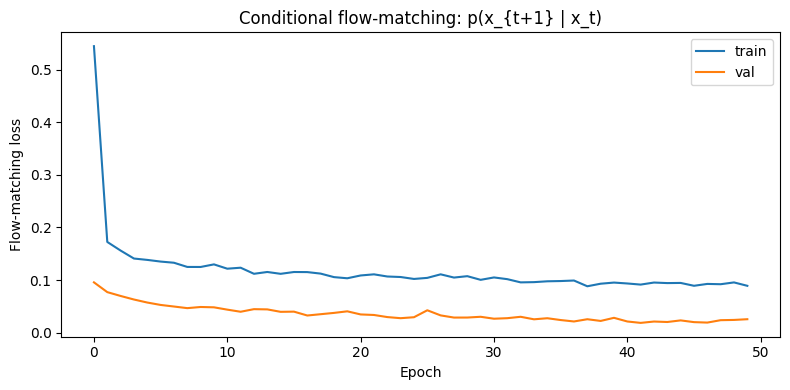

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='train')
plt.plot(val_losses,   label='val')
plt.xlabel('Epoch')
plt.ylabel('Flow-matching loss')
plt.title('Conditional flow-matching: p(x_{t+1} | x_t)')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Sanity Check — sample one forecast

Given conditioning state $x_t$, integrate the flow ODE from noise ($s=0$) to data ($s=1$)
to get predicted $\hat{x}_{t+1}$, then compare with the ground truth.

/tmp/ipykernel_5735/136363428.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(SAVE_PATH, map_location=device))


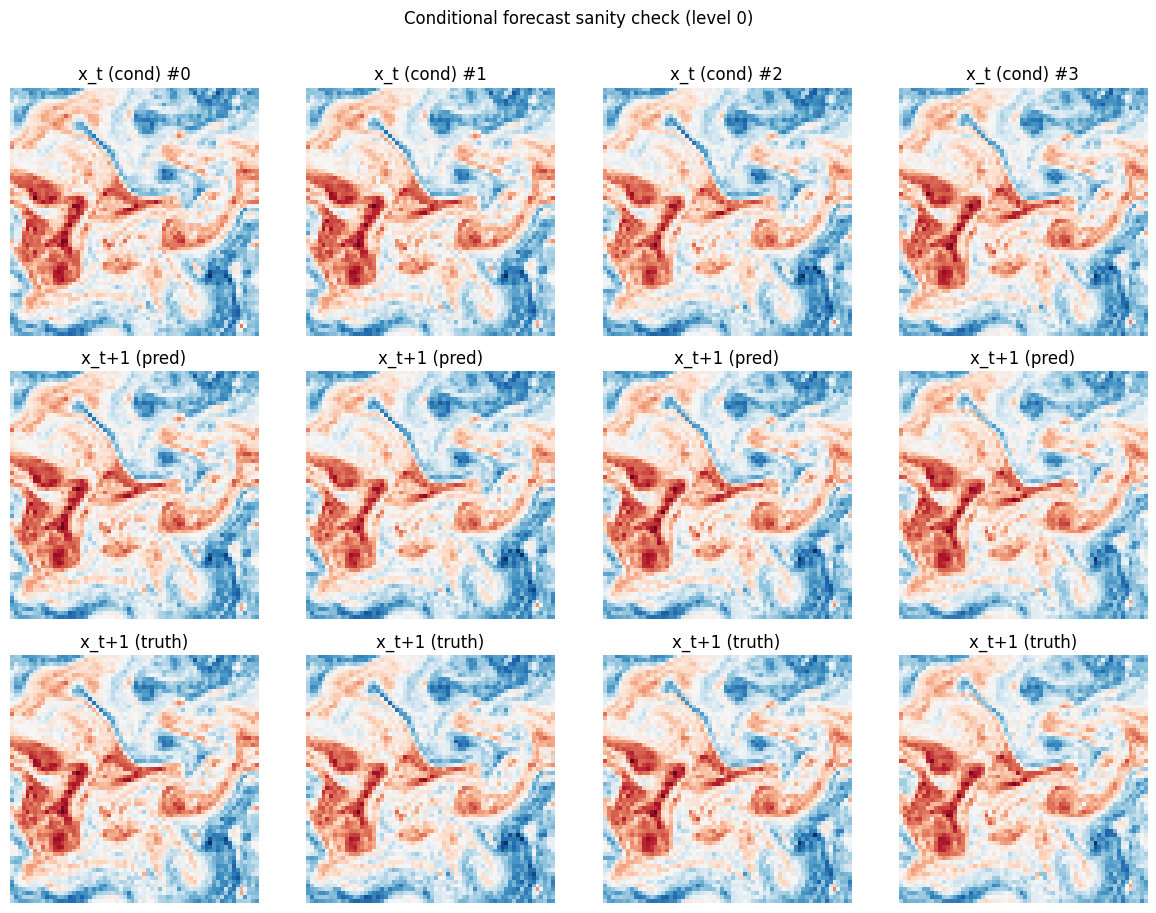

In [9]:
def sample_conditional(model, x_t, steps=100):
    """
    Euler integration of the conditional flow ODE.

    dz/ds = b(z_s, s, x_t),   s from 0 (noise) to 1 (forecast)

    Args:
        model  : trained SongUNet
        x_t    : conditioning state, shape (B, C, H, W)
        steps  : number of Euler steps

    Returns:
        predicted x_{t+1}, shape (B, C, H, W)
    """
    model.eval()
    B  = x_t.shape[0]
    dt = 1.0 / steps

    with torch.no_grad():
        z = torch.randn_like(x_t)                          # start from noise at s=0
        for i in range(steps):
            s = torch.full((B,), i * dt, device=x_t.device)
            b = model(z, s, class_labels=x_t)              # predicted velocity
            z = z + b * dt                                 # Euler step forward

    return z   # z at s=1  ~  x_{t+1} | x_t


# load best checkpoint
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))

x_t_sample, x_t1_truth = next(iter(val_loader))
x_t_sample = x_t_sample[:4].to(device)
x_t1_truth = x_t1_truth[:4]

x_t1_pred = sample_conditional(model, x_t_sample, steps=100).cpu()

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for i in range(4):
    axes[0, i].imshow(x_t_sample[i, 0].cpu(), cmap='RdBu_r')
    axes[0, i].set_title(f'x_t (cond) #{i}')
    axes[1, i].imshow(x_t1_pred[i, 0],        cmap='RdBu_r')
    axes[1, i].set_title('x_t+1 (pred)')
    axes[2, i].imshow(x_t1_truth[i, 0],       cmap='RdBu_r')
    axes[2, i].set_title('x_t+1 (truth)')
    for row in axes:
        row[i].axis('off')

plt.suptitle('Conditional forecast sanity check (level 0)', y=1.01)
plt.tight_layout()
plt.show()